In [477]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [478]:
df = pd.read_csv('/home/mahes/repos/t20_cricket_score_predictor/data/IPL.csv')
df.head()


,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_balls,team_wicket,new_batter,power_surge_start,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,141607,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,141608,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,2,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,141609,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,141610,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,3,0,NaN,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,141611,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,4,0,NaN,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [479]:
df.describe()

,Unnamed: 0,match_id,innings,over,ball,ball_no,bat_pos,runs_batter,balls_faced,valid_ball,...,year,balls_per_over,overs,team_runs,team_balls,team_wicket,power_surge_start,batter_runs,batter_balls,bowler_wicket
count,283678.000000,2.836780e+05,283678.000000,283678.000000,283678.000000,283678.000000,283678.000000,283678.000000,283678.000000,283678.000000,...,283678.000000,283678.0,283678.0,283678.000000,283678.000000,283678.000000,0.0,283678.000000,283678.000000,283678.000000
mean,141838.500000,9.535684e+05,1.482787,9.190833,3.488847,9.539717,3.616445,1.281421,0.967082,0.962912,...,2016.889406,6.0,20.0,77.423099,58.596328,2.460624,NaN,18.376621,13.993813,0.045530
std,81890.929169,3.865091e+05,0.502511,5.680845,1.708286,5.682271,2.170569,1.655126,0.178421,0.188977,...,5.352468,0.0,0.0,50.167985,34.113517,2.102515,NaN,18.607095,11.815576,0.208465
min,0.000000,3.359820e+05,1.000000,0.000000,1.000000,0.100000,1.000000,0.000000,0.000000,0.000000,...,2008.000000,6.0,20.0,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000
25%,70919.250000,5.483590e+05,1.000000,4.000000,2.000000,4.500000,2.000000,0.000000,1.000000,1.000000,...,2012.000000,6.0,20.0,36.000000,29.000000,1.000000,NaN,4.000000,5.000000,0.000000
50%,141838.500000,1.082612e+06,1.000000,9.000000,3.000000,9.400000,3.000000,1.000000,1.000000,1.000000,...,2017.000000,6.0,20.0,73.000000,58.000000,2.000000,NaN,12.000000,11.000000,0.000000
75%,212757.750000,1.304066e+06,2.000000,14.000000,5.000000,14.400000,5.000000,1.000000,1.000000,1.000000,...,2022.000000,6.0,20.0,114.000000,88.000000,4.000000,NaN,27.000000,20.000000,0.000000
max,283677.000000,1.529267e+06,6.000000,19.000000,7.000000,19.600000,11.000000,6.000000,1.000000,1.000000,...,2026.000000,6.0,20.0,287.000000,121.000000,10.000000,NaN,175.000000,73.000000,1.000000


In [480]:
df.shape

(283678, 65)

In [481]:
df.columns

Index(['Unnamed: 0', 'match_id', 'date', 'match_type', 'event_name', 'innings',
       'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter',
       'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball',
       'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary',
       'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind',
       'player_out', 'fielders', 'runs_target', 'review_batter',
       'team_reviewed', 'review_decision', 'umpire', 'umpires_call',
       'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner',
       'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season',
       'gender', 'team_type', 'superover_winner', 'result_type', 'method',
       'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number',
       'team_runs', 'team_balls', 'team_wicket', 'new_batter',
       'power_surge_start', 'batter_runs', 'batter_balls', 'bowler_wicket',
       'batting_partners', 'next_batter', 'striker_out'],


In [482]:
df.isnull().sum()

Unnamed: 0               0
match_id                 0
date                     0
match_type               0
event_name               0
                     ...  
batter_balls             0
bowler_wicket            0
batting_partners         0
next_batter         270085
striker_out              0
Length: 65, dtype: int64

In [483]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 283678 entries, 0 to 283677
Data columns (total 65 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         283678 non-null  int64  
 1   match_id           283678 non-null  int64  
 2   date               283678 non-null  str    
 3   match_type         283678 non-null  str    
 4   event_name         283678 non-null  str    
 5   innings            283678 non-null  int64  
 6   batting_team       283678 non-null  str    
 7   bowling_team       283678 non-null  str    
 8   over               283678 non-null  int64  
 9   ball               283678 non-null  int64  
 10  ball_no            283678 non-null  float64
 11  batter             283678 non-null  str    
 12  bat_pos            283678 non-null  int64  
 13  runs_batter        283678 non-null  int64  
 14  balls_faced        283678 non-null  int64  
 15  bowler             283678 non-null  str    
 16  valid_ball   

In [484]:
df['bat_pos'].value_counts()
df['ball'] 

0         1
1         2
2         3
3         3
4         4
         ..
283673    1
283674    1
283675    2
283676    3
283677    3
Name: ball, Length: 283678, dtype: int64

In [485]:
df['win_outcome'].head()

0    140 runs
1    140 runs
2    140 runs
3    140 runs
4    140 runs
Name: win_outcome, dtype: str

In [486]:
df['team_balls'].value_counts()

team_balls
6      2564
1      2554
2      2520
3      2507
4      2507
       ... 
118    1784
119    1694
120    1556
0       158
121       1
Name: count, Length: 122, dtype: int64

In [487]:
df['stage'].value_counts()

stage
Unknown               266965
Final                   4338
Qualifier 2             3636
Qualifier 1             3553
Eliminator              2845
Semi Final              1409
Elimination Final        734
3rd Place Play-Off       198
Name: count, dtype: int64

In [488]:
removable_columns = ['event_name','match_type','Unnamed: 0','power_surge_start','gender','over','ball_no','superover_winner','player_of_match','ball','balls_per_over','umpire','team_type','method','event_match_no','date','month','day']
df.drop(removable_columns, axis=1, inplace=True)
df.head()

,match_id,innings,batting_team,bowling_team,batter,bat_pos,runs_batter,balls_faced,bowler,valid_ball,...,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,1,0,1,P Kumar,1,...,1,1,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,2,0,1,P Kumar,1,...,1,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,2,0,0,P Kumar,0,...,2,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,2,0,1,P Kumar,1,...,2,3,0,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,2,0,1,P Kumar,1,...,2,4,0,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [489]:
df['venue'].value_counts()

venue
Eden Gardens                                                               17988
Wankhede Stadium                                                           17591
M Chinnaswamy Stadium                                                      14907
Feroz Shah Kotla                                                           13950
Wankhede Stadium, Mumbai                                                   13289
MA Chidambaram Stadium, Chepauk                                            11760
Rajiv Gandhi International Stadium, Uppal                                  11604
Dubai International Cricket Stadium                                        11229
Sawai Mansingh Stadium                                                     11150
MA Chidambaram Stadium, Chepauk, Chennai                                    9000
Punjab Cricket Association Stadium, Mohali                                  8266
Narendra Modi Stadium, Ahmedabad                                            8176
Sheikh Zayed Stadium  

In [490]:
df.tail()

,match_id,innings,batting_team,bowling_team,batter,bat_pos,runs_batter,balls_faced,bowler,valid_ball,...,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
283673,1529267,2,Punjab Kings,Mumbai Indians,MP Stoinis,5,0,0,DL Chahar,0,...,189,96,3,NaN,2,2,0,"('MP Stoinis', 'P Simran Singh')",NaN,False
283674,1529267,2,Punjab Kings,Mumbai Indians,MP Stoinis,5,0,1,DL Chahar,1,...,189,97,3,NaN,2,3,0,"('MP Stoinis', 'P Simran Singh')",NaN,False
283675,1529267,2,Punjab Kings,Mumbai Indians,MP Stoinis,5,4,1,DL Chahar,1,...,193,98,3,NaN,6,4,0,"('MP Stoinis', 'P Simran Singh')",NaN,False
283676,1529267,2,Punjab Kings,Mumbai Indians,MP Stoinis,5,0,0,DL Chahar,0,...,194,98,3,NaN,6,4,0,"('MP Stoinis', 'P Simran Singh')",NaN,False
283677,1529267,2,Punjab Kings,Mumbai Indians,MP Stoinis,5,4,1,DL Chahar,1,...,198,99,3,NaN,10,5,0,"('MP Stoinis', 'P Simran Singh')",NaN,False


In [491]:
df.head()

,match_id,innings,batting_team,bowling_team,batter,bat_pos,runs_batter,balls_faced,bowler,valid_ball,...,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,1,0,1,P Kumar,1,...,1,1,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,2,0,1,P Kumar,1,...,1,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,2,0,0,P Kumar,0,...,2,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,2,0,1,P Kumar,1,...,2,3,0,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,2,0,1,P Kumar,1,...,2,4,0,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [492]:
df.columns

Index(['match_id', 'innings', 'batting_team', 'bowling_team', 'batter',
       'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball',
       'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary',
       'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind',
       'player_out', 'fielders', 'runs_target', 'review_batter',
       'team_reviewed', 'review_decision', 'umpires_call', 'match_won_by',
       'win_outcome', 'toss_winner', 'toss_decision', 'venue', 'city', 'year',
       'season', 'result_type', 'overs', 'stage', 'match_number', 'team_runs',
       'team_balls', 'team_wicket', 'new_batter', 'batter_runs',
       'batter_balls', 'bowler_wicket', 'batting_partners', 'next_batter',
       'striker_out'],
      dtype='str')

In [493]:
df['innings'].value_counts()

innings
1    146997
2    136510
3        83
4        76
5         8
6         4
Name: count, dtype: int64

In [494]:
df[df['innings'] == 3].head(14)

,match_id,innings,batting_team,bowling_team,batter,bat_pos,runs_batter,balls_faced,bowler,valid_ball,...,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
15417,392190,3,Kolkata Knight Riders,Rajasthan Royals,CH Gayle,1,1,1,Kamran Khan,1,...,1,1,0,NaN,1,1,0,"('BB McCullum', 'CH Gayle')",NaN,False
15418,392190,3,Kolkata Knight Riders,Rajasthan Royals,BB McCullum,2,1,1,Kamran Khan,1,...,2,2,0,NaN,1,1,0,"('BB McCullum', 'CH Gayle')",NaN,False
15419,392190,3,Kolkata Knight Riders,Rajasthan Royals,CH Gayle,1,0,0,Kamran Khan,0,...,3,2,0,NaN,1,1,0,"('BB McCullum', 'CH Gayle')",NaN,False
15420,392190,3,Kolkata Knight Riders,Rajasthan Royals,CH Gayle,1,4,1,Kamran Khan,1,...,7,3,0,NaN,5,2,0,"('BB McCullum', 'CH Gayle')",NaN,False
15421,392190,3,Kolkata Knight Riders,Rajasthan Royals,CH Gayle,1,4,1,Kamran Khan,1,...,11,4,0,NaN,9,3,0,"('BB McCullum', 'CH Gayle')",NaN,False
15422,392190,3,Kolkata Knight Riders,Rajasthan Royals,CH Gayle,1,4,1,Kamran Khan,1,...,15,5,0,NaN,13,4,0,"('BB McCullum', 'CH Gayle')",NaN,False
15423,392190,3,Kolkata Knight Riders,Rajasthan Royals,CH Gayle,1,0,1,Kamran Khan,1,...,15,6,1,NaN,13,5,1,"('BB McCullum', 'CH Gayle')",NaN,True
30957,419121,3,Chennai Super Kings,Kings XI Punjab,JA Morkel,1,1,1,J Theron,1,...,1,1,0,NaN,1,1,0,"('JA Morkel', 'ML Hayden')",NaN,False
30958,419121,3,Chennai Super Kings,Kings XI Punjab,ML Hayden,2,0,1,J Theron,1,...,1,2,1,NaN,0,1,1,"('JA Morkel', 'ML Hayden')",SK Raina,True
30959,419121,3,Chennai Super Kings,Kings XI Punjab,SK Raina,3,2,1,J Theron,1,...,3,3,1,SK Raina,2,1,0,"('JA Morkel', 'SK Raina')",NaN,False


In [495]:
## inning 1 and 2 are only the required innings
df = df.drop(df[df['innings'] > 2].index)
df.head()

,match_id,innings,batting_team,bowling_team,batter,bat_pos,runs_batter,balls_faced,bowler,valid_ball,...,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,1,0,1,P Kumar,1,...,1,1,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,2,0,1,P Kumar,1,...,1,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,2,0,0,P Kumar,0,...,2,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,2,0,1,P Kumar,1,...,2,3,0,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,2,0,1,P Kumar,1,...,2,4,0,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [496]:
df['innings'].value_counts()

innings
1    146997
2    136510
Name: count, dtype: int64

In [497]:
df.columns

Index(['match_id', 'innings', 'batting_team', 'bowling_team', 'batter',
       'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball',
       'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary',
       'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind',
       'player_out', 'fielders', 'runs_target', 'review_batter',
       'team_reviewed', 'review_decision', 'umpires_call', 'match_won_by',
       'win_outcome', 'toss_winner', 'toss_decision', 'venue', 'city', 'year',
       'season', 'result_type', 'overs', 'stage', 'match_number', 'team_runs',
       'team_balls', 'team_wicket', 'new_batter', 'batter_runs',
       'batter_balls', 'bowler_wicket', 'batting_partners', 'next_batter',
       'striker_out'],
      dtype='str')

In [498]:
df['city'].value_counts()

city
Mumbai            44109
Kolkata           23942
Delhi             23462
Chennai           22869
Hyderabad         20144
Jaipur            15194
Bangalore         14895
Chandigarh        14476
Unknown           12355
Pune              12239
Ahmedabad         11058
Abu Dhabi          8780
Bengaluru          8731
Lucknow            5701
Visakhapatnam      4000
Durban             3643
Dharamsala         3457
Dubai              3149
Centurion          2866
Rajkot             2368
Sharjah            2355
Navi Mumbai        2188
Mohali             2166
Indore             1965
Johannesburg       1940
Guwahati           1799
Cuttack            1695
Port Elizabeth     1677
Ranchi             1671
Cape Town          1528
Raipur             1431
Kochi              1155
Kanpur              921
New Chandigarh      895
Nagpur              742
Kimberley           726
East London         715
Bloemfontein        500
Name: count, dtype: int64

In [499]:
df['venue']

0            M Chinnaswamy Stadium
1            M Chinnaswamy Stadium
2            M Chinnaswamy Stadium
3            M Chinnaswamy Stadium
4            M Chinnaswamy Stadium
                    ...           
283673    Wankhede Stadium, Mumbai
283674    Wankhede Stadium, Mumbai
283675    Wankhede Stadium, Mumbai
283676    Wankhede Stadium, Mumbai
283677    Wankhede Stadium, Mumbai
Name: venue, Length: 283507, dtype: str

In [500]:
df.columns

Index(['match_id', 'innings', 'batting_team', 'bowling_team', 'batter',
       'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball',
       'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary',
       'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind',
       'player_out', 'fielders', 'runs_target', 'review_batter',
       'team_reviewed', 'review_decision', 'umpires_call', 'match_won_by',
       'win_outcome', 'toss_winner', 'toss_decision', 'venue', 'city', 'year',
       'season', 'result_type', 'overs', 'stage', 'match_number', 'team_runs',
       'team_balls', 'team_wicket', 'new_batter', 'batter_runs',
       'batter_balls', 'bowler_wicket', 'batting_partners', 'next_batter',
       'striker_out'],
      dtype='str')

In [501]:
df.shape

(283507, 47)

In [502]:
df['year'].value_counts()

year
2013    18152
2022    17912
2023    17863
2012    17767
2025    17275
2024    17103
2011    17013
2020    14510
2010    14489
2021    14413
2019    14293
2014    14288
2018    14286
2016    14096
2017    13849
2015    13641
2009    13595
2008    13489
2026     5473
Name: count, dtype: int64

In [503]:
df_latest = df[df['year'] > 2015]
df_latest.shape

(161073, 47)

In [504]:
df_latest.head()

,match_id,innings,batting_team,bowling_team,batter,bat_pos,runs_batter,balls_faced,bowler,valid_ball,...,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
122502,980901,1,Mumbai Indians,Rising Pune Supergiants,LMP Simmons,1,1,1,RP Singh,1,...,1,1,0,NaN,1,1,0,"('LMP Simmons', 'RG Sharma')",NaN,False
122503,980901,1,Mumbai Indians,Rising Pune Supergiants,RG Sharma,2,0,1,RP Singh,1,...,1,2,0,NaN,0,1,0,"('LMP Simmons', 'RG Sharma')",NaN,False
122504,980901,1,Mumbai Indians,Rising Pune Supergiants,RG Sharma,2,2,1,RP Singh,1,...,3,3,0,NaN,2,2,0,"('LMP Simmons', 'RG Sharma')",NaN,False
122505,980901,1,Mumbai Indians,Rising Pune Supergiants,RG Sharma,2,4,1,RP Singh,1,...,7,4,0,NaN,6,3,0,"('LMP Simmons', 'RG Sharma')",NaN,False
122506,980901,1,Mumbai Indians,Rising Pune Supergiants,RG Sharma,2,1,1,RP Singh,1,...,8,5,0,NaN,7,4,0,"('LMP Simmons', 'RG Sharma')",NaN,False


In [505]:
df_latest['valid_ball'].value_counts()

valid_ball
1    154812
0      6261
Name: count, dtype: int64

In [506]:
df_latest.columns

Index(['match_id', 'innings', 'batting_team', 'bowling_team', 'batter',
       'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball',
       'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary',
       'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind',
       'player_out', 'fielders', 'runs_target', 'review_batter',
       'team_reviewed', 'review_decision', 'umpires_call', 'match_won_by',
       'win_outcome', 'toss_winner', 'toss_decision', 'venue', 'city', 'year',
       'season', 'result_type', 'overs', 'stage', 'match_number', 'team_runs',
       'team_balls', 'team_wicket', 'new_batter', 'batter_runs',
       'batter_balls', 'bowler_wicket', 'batting_partners', 'next_batter',
       'striker_out'],
      dtype='str')

In [507]:
df['match_won_by'].value_counts()

match_won_by
Mumbai Indians                 36432
Chennai Super Kings            34878
Kolkata Knight Riders          31729
Rajasthan Royals               28295
Royal Challengers Bangalore    26801
Sunrisers Hyderabad            22665
Kings XI Punjab                20162
Delhi Daredevils               15709
Delhi Capitals                 12762
Gujarat Titans                  9491
Punjab Kings                    9142
Lucknow Super Giants            7925
Deccan Chargers                 7013
Royal Challengers Bengaluru     5194
Unknown                         4553
Gujarat Lions                   3063
Pune Warriors                   2883
Rising Pune Supergiant          2383
Kochi Tuskers Kerala            1322
Rising Pune Supergiants         1105
Name: count, dtype: int64

In [508]:
df_latest.drop(columns=['city','batter','non_striker','umpires_call','team_reviewed','non_striker_pos','extra_type','fielders','toss_winner','new_batter','next_batter','batting_partners','season','review_batter','review_decision','overs','match_number','result_type','bowler_wicket','striker_out','runs_target'], inplace=True)

In [509]:
df_latest.shape

(161073, 26)

In [510]:
df_latest.head()

,match_id,innings,batting_team,bowling_team,bat_pos,runs_batter,balls_faced,bowler,valid_ball,runs_extras,...,win_outcome,toss_decision,venue,year,stage,team_runs,team_balls,team_wicket,batter_runs,batter_balls
122502,980901,1,Mumbai Indians,Rising Pune Supergiants,1,1,1,RP Singh,1,0,...,9 wickets,bat,Wankhede Stadium,2016,Unknown,1,1,0,1,1
122503,980901,1,Mumbai Indians,Rising Pune Supergiants,2,0,1,RP Singh,1,0,...,9 wickets,bat,Wankhede Stadium,2016,Unknown,1,2,0,0,1
122504,980901,1,Mumbai Indians,Rising Pune Supergiants,2,2,1,RP Singh,1,0,...,9 wickets,bat,Wankhede Stadium,2016,Unknown,3,3,0,2,2
122505,980901,1,Mumbai Indians,Rising Pune Supergiants,2,4,1,RP Singh,1,0,...,9 wickets,bat,Wankhede Stadium,2016,Unknown,7,4,0,6,3
122506,980901,1,Mumbai Indians,Rising Pune Supergiants,2,1,1,RP Singh,1,0,...,9 wickets,bat,Wankhede Stadium,2016,Unknown,8,5,0,7,4


In [511]:
df_latest.columns

Index(['match_id', 'innings', 'batting_team', 'bowling_team', 'bat_pos',
       'runs_batter', 'balls_faced', 'bowler', 'valid_ball', 'runs_extras',
       'runs_total', 'runs_bowler', 'runs_not_boundary', 'wicket_kind',
       'player_out', 'match_won_by', 'win_outcome', 'toss_decision', 'venue',
       'year', 'stage', 'team_runs', 'team_balls', 'team_wicket',
       'batter_runs', 'batter_balls'],
      dtype='str')

In [512]:
print(df_latest)

        match_id  innings    batting_team             bowling_team  bat_pos  \
122502    980901        1  Mumbai Indians  Rising Pune Supergiants        1   
122503    980901        1  Mumbai Indians  Rising Pune Supergiants        2   
122504    980901        1  Mumbai Indians  Rising Pune Supergiants        2   
122505    980901        1  Mumbai Indians  Rising Pune Supergiants        2   
122506    980901        1  Mumbai Indians  Rising Pune Supergiants        2   
...          ...      ...             ...                      ...      ...   
283673   1529267        2    Punjab Kings           Mumbai Indians        5   
283674   1529267        2    Punjab Kings           Mumbai Indians        5   
283675   1529267        2    Punjab Kings           Mumbai Indians        5   
283676   1529267        2    Punjab Kings           Mumbai Indians        5   
283677   1529267        2    Punjab Kings           Mumbai Indians        5   

        runs_batter  balls_faced     bowler  valid_

In [513]:
df_copy = df_latest.copy()
df_copy.head()

,match_id,innings,batting_team,bowling_team,bat_pos,runs_batter,balls_faced,bowler,valid_ball,runs_extras,...,win_outcome,toss_decision,venue,year,stage,team_runs,team_balls,team_wicket,batter_runs,batter_balls
122502,980901,1,Mumbai Indians,Rising Pune Supergiants,1,1,1,RP Singh,1,0,...,9 wickets,bat,Wankhede Stadium,2016,Unknown,1,1,0,1,1
122503,980901,1,Mumbai Indians,Rising Pune Supergiants,2,0,1,RP Singh,1,0,...,9 wickets,bat,Wankhede Stadium,2016,Unknown,1,2,0,0,1
122504,980901,1,Mumbai Indians,Rising Pune Supergiants,2,2,1,RP Singh,1,0,...,9 wickets,bat,Wankhede Stadium,2016,Unknown,3,3,0,2,2
122505,980901,1,Mumbai Indians,Rising Pune Supergiants,2,4,1,RP Singh,1,0,...,9 wickets,bat,Wankhede Stadium,2016,Unknown,7,4,0,6,3
122506,980901,1,Mumbai Indians,Rising Pune Supergiants,2,1,1,RP Singh,1,0,...,9 wickets,bat,Wankhede Stadium,2016,Unknown,8,5,0,7,4


In [514]:
print(df_copy)

        match_id  innings    batting_team             bowling_team  bat_pos  \
122502    980901        1  Mumbai Indians  Rising Pune Supergiants        1   
122503    980901        1  Mumbai Indians  Rising Pune Supergiants        2   
122504    980901        1  Mumbai Indians  Rising Pune Supergiants        2   
122505    980901        1  Mumbai Indians  Rising Pune Supergiants        2   
122506    980901        1  Mumbai Indians  Rising Pune Supergiants        2   
...          ...      ...             ...                      ...      ...   
283673   1529267        2    Punjab Kings           Mumbai Indians        5   
283674   1529267        2    Punjab Kings           Mumbai Indians        5   
283675   1529267        2    Punjab Kings           Mumbai Indians        5   
283676   1529267        2    Punjab Kings           Mumbai Indians        5   
283677   1529267        2    Punjab Kings           Mumbai Indians        5   

        runs_batter  balls_faced     bowler  valid_

In [515]:
df_copy['win_outcome']

122502    9 wickets
122503    9 wickets
122504    9 wickets
122505    9 wickets
122506    9 wickets
            ...    
283673    7 wickets
283674    7 wickets
283675    7 wickets
283676    7 wickets
283677    7 wickets
Name: win_outcome, Length: 161073, dtype: str

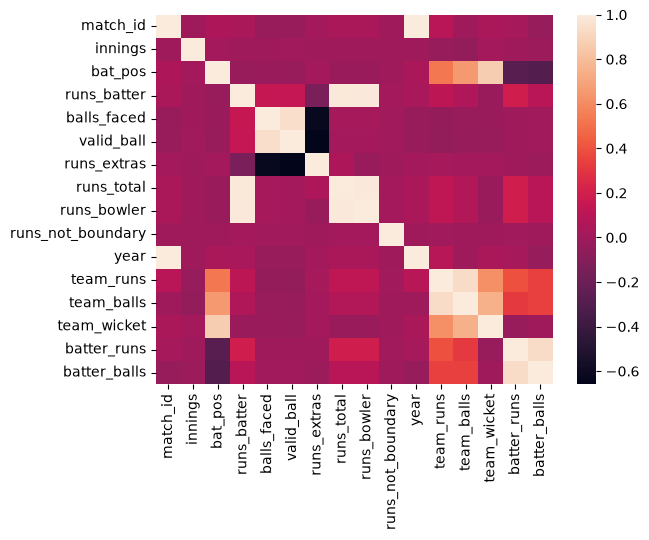

In [516]:
sns.heatmap(df_copy.corr(numeric_only=True))
plt.show()

In [517]:
df_copy['team_runs'].tail()

283673    189
283674    189
283675    193
283676    194
283677    198
Name: team_runs, dtype: int64

In [518]:
numeric_columns = df_copy.select_dtypes(include=np.number).columns
print(numeric_columns)

Index(['match_id', 'innings', 'bat_pos', 'runs_batter', 'balls_faced',
       'valid_ball', 'runs_extras', 'runs_total', 'runs_bowler', 'year',
       'team_runs', 'team_balls', 'team_wicket', 'batter_runs',
       'batter_balls'],
      dtype='str')


In [519]:
categorical_columns = df_copy.select_dtypes(include='str').columns
print(categorical_columns)

Index(['batting_team', 'bowling_team', 'bowler', 'wicket_kind', 'player_out',
       'match_won_by', 'win_outcome', 'toss_decision', 'venue', 'stage'],
      dtype='str')


In [520]:
df_copy['batting_team'].value_counts()

batting_team
Sunrisers Hyderabad            18720
Mumbai Indians                 18648
Kolkata Knight Riders          17621
Chennai Super Kings            15273
Rajasthan Royals               14510
Royal Challengers Bangalore    13972
Delhi Capitals                 13081
Punjab Kings                    9331
Kings XI Punjab                 8303
Gujarat Titans                  7827
Lucknow Super Giants            7750
Delhi Daredevils                4896
Royal Challengers Bengaluru     4103
Gujarat Lions                   3558
Rising Pune Supergiant          1900
Rising Pune Supergiants         1580
Name: count, dtype: int64

In [521]:
team_short_names = {
    "Mumbai Indians": "MI",
    "Chennai Super Kings": "CSK",
    "Royal Challengers Bangalore": "RCB",
    "Royal Challengers Bengaluru": "RCB",
    "Kolkata Knight Riders": "KKR",
    "Rajasthan Royals": "RR",
    "Sunrisers Hyderabad": "SRH",
    "Kings XI Punjab": "PBKS",
    "Punjab Kings": "PBKS",
    "Delhi Daredevils": "DC",
    "Delhi Capitals": "DC",
    "Deccan Chargers": "DCG",
    "Gujarat Titans": "GT",
    "Lucknow Super Giants": "LSG",
    "Pune Warriors": "PWI",
    "Gujarat Lions": "GL",
    "Rising Pune Supergiant": "RPS",
    "Rising Pune Supergiants": "RPS",
    "Kochi Tuskers Kerala": "KTK"
}

In [522]:
df_copy["batting_team"] = df_copy["batting_team"].map(team_short_names)
df_copy["bowling_team"] = df_copy["bowling_team"].map(team_short_names)
df_copy["match_won_by"] = df_copy["match_won_by"].map(team_short_names)

In [523]:
df_copy.shape


(161073, 26)

In [524]:
df_copy.head()

,match_id,innings,batting_team,bowling_team,bat_pos,runs_batter,balls_faced,bowler,valid_ball,runs_extras,...,win_outcome,toss_decision,venue,year,stage,team_runs,team_balls,team_wicket,batter_runs,batter_balls
122502,980901,1,MI,RPS,1,1,1,RP Singh,1,0,...,9 wickets,bat,Wankhede Stadium,2016,Unknown,1,1,0,1,1
122503,980901,1,MI,RPS,2,0,1,RP Singh,1,0,...,9 wickets,bat,Wankhede Stadium,2016,Unknown,1,2,0,0,1
122504,980901,1,MI,RPS,2,2,1,RP Singh,1,0,...,9 wickets,bat,Wankhede Stadium,2016,Unknown,3,3,0,2,2
122505,980901,1,MI,RPS,2,4,1,RP Singh,1,0,...,9 wickets,bat,Wankhede Stadium,2016,Unknown,7,4,0,6,3
122506,980901,1,MI,RPS,2,1,1,RP Singh,1,0,...,9 wickets,bat,Wankhede Stadium,2016,Unknown,8,5,0,7,4


In [525]:
len(numeric_columns) + len(categorical_columns)

25

<Axes: xlabel='team_runs', ylabel='team_balls'>

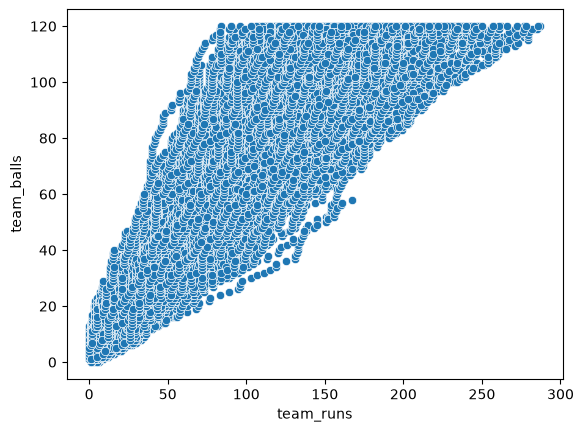

In [526]:
sns.scatterplot(x='team_runs', y='team_balls', data=df_copy)

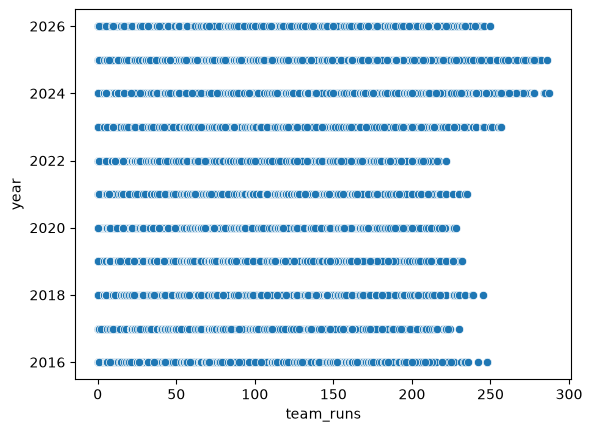

In [527]:

sns.scatterplot(x='team_runs',y='year',data= df_copy)
plt.show()

In [528]:
# sns.pairplot(df_copy)
# plt.show()

<Axes: xlabel='team_runs', ylabel='Count'>

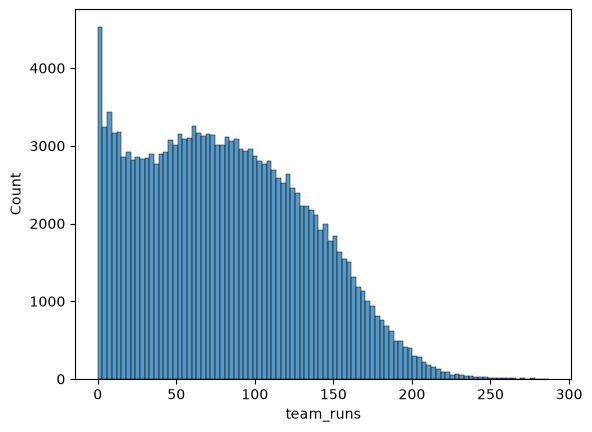

In [529]:
sns.histplot(df_copy['team_runs'])

<Axes: xlabel='team_wicket', ylabel='Count'>

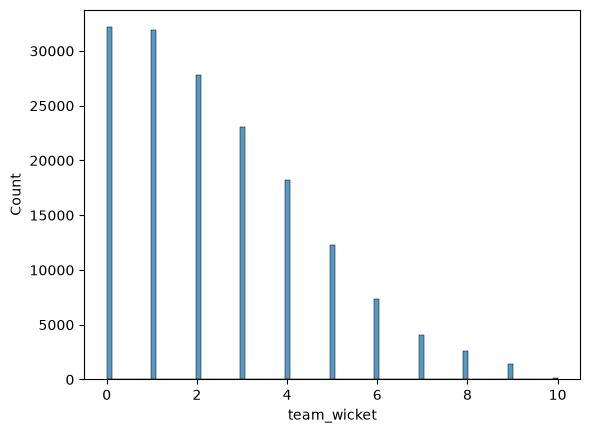

In [530]:
sns.histplot(df_copy['team_wicket'])

In [531]:
df_copy["team_final_score"] = (
    df_copy.groupby(["match_id", "innings"])["team_runs"]
      .transform("max")
)

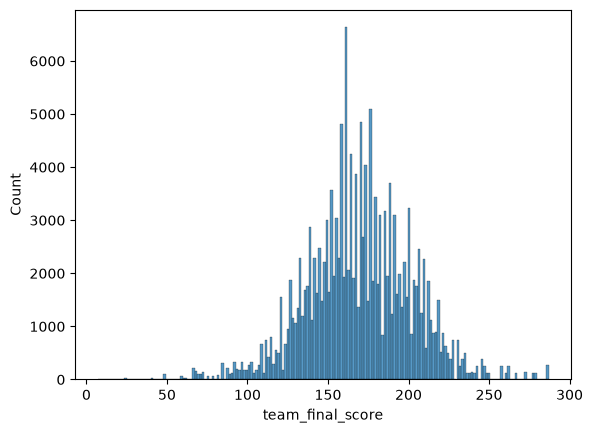

In [532]:
sns.histplot(df_copy['team_final_score'])
plt.show()

In [533]:
df_copy.head()

,match_id,innings,batting_team,bowling_team,bat_pos,runs_batter,balls_faced,bowler,valid_ball,runs_extras,...,toss_decision,venue,year,stage,team_runs,team_balls,team_wicket,batter_runs,batter_balls,team_final_score
122502,980901,1,MI,RPS,1,1,1,RP Singh,1,0,...,bat,Wankhede Stadium,2016,Unknown,1,1,0,1,1,121
122503,980901,1,MI,RPS,2,0,1,RP Singh,1,0,...,bat,Wankhede Stadium,2016,Unknown,1,2,0,0,1,121
122504,980901,1,MI,RPS,2,2,1,RP Singh,1,0,...,bat,Wankhede Stadium,2016,Unknown,3,3,0,2,2,121
122505,980901,1,MI,RPS,2,4,1,RP Singh,1,0,...,bat,Wankhede Stadium,2016,Unknown,7,4,0,6,3,121
122506,980901,1,MI,RPS,2,1,1,RP Singh,1,0,...,bat,Wankhede Stadium,2016,Unknown,8,5,0,7,4,121


In [534]:
df_copy['toss_decision'].value_counts()

toss_decision
field    124090
bat       36983
Name: count, dtype: int64

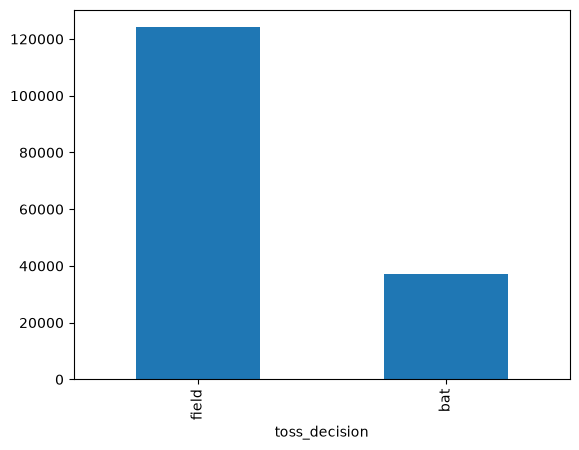

In [535]:
df_copy['toss_decision'].value_counts().plot.bar()
plt.show()

In [536]:
df_copy['toss_decision'] = df_copy['toss_decision'].map({'field': 0, 'bat': 1})
df_copy['toss_decision'].value_counts()

toss_decision
0    124090
1     36983
Name: count, dtype: int64

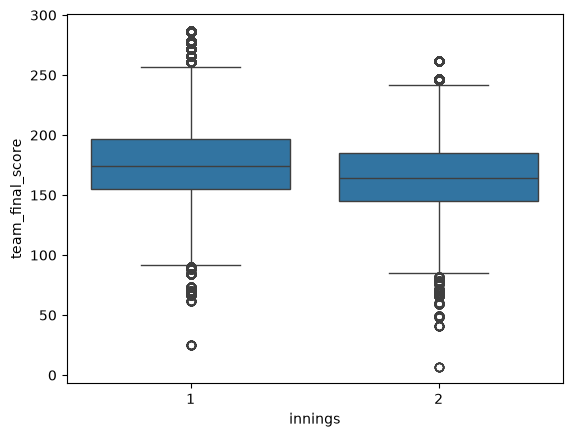

In [537]:
sns.boxplot(x= 'innings', y = 'team_final_score', data = df_copy)
plt.show()

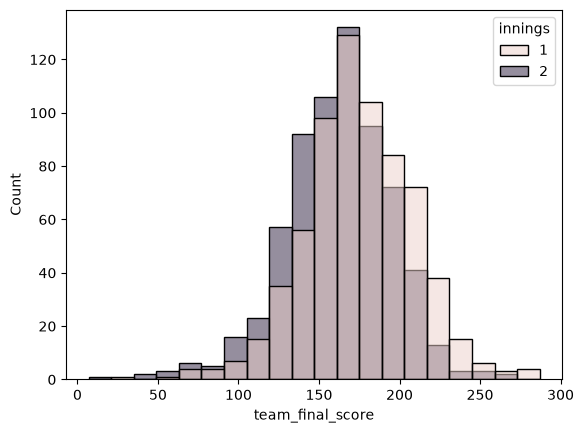

In [538]:
innings_scores = df_copy.drop_duplicates(subset=["match_id", "innings"])

sns.histplot(
    data=innings_scores,
    x="team_final_score",
    hue="innings",
    bins=20,
    multiple="layer",
    alpha=0.5
)

plt.show()

In [539]:
categorical_columns

Index(['batting_team', 'bowling_team', 'bowler', 'wicket_kind', 'player_out',
       'match_won_by', 'win_outcome', 'toss_decision', 'venue', 'stage'],
      dtype='str')

In [540]:
df_copy['bowling_team'].value_counts()

bowling_team
MI      18800
SRH     18632
DC      18206
RCB     18021
KKR     17878
PBKS    17433
CSK     15221
RR      14651
GT       7643
LSG      7505
RPS      3543
GL       3540
Name: count, dtype: int64

In [541]:
df_copy['wicket_kind'].value_counts()

wicket_kind
caught                   5320
bowled                   1234
run out                   541
lbw                       502
caught and bowled         221
stumped                   178
hit wicket                 13
retired hurt               11
retired out                 6
obstructing the field       2
Name: count, dtype: int64

In [542]:
df_copy['win_outcome'].value_counts()

win_outcome
6 wickets    19746
7 wickets    16456
5 wickets    13080
8 wickets    11036
4 wickets     9039
             ...  
86 runs        224
71 runs        213
146 runs       211
75 runs        211
112 runs       189
Name: count, Length: 98, dtype: int64

In [543]:
df_copy['match_won_by'].value_counts()

match_won_by
MI      18840
RCB     18178
SRH     17499
KKR     17427
DC      17025
CSK     15883
PBKS    15802
RR      13717
GT       9491
LSG      7925
RPS      3488
GL       3063
Name: count, dtype: int64

In [544]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [545]:
df_copy['stage'].unique()

<StringArray>
[          'Unknown',       'Qualifier 1', 'Elimination Final',
       'Qualifier 2',             'Final',        'Eliminator']
Length: 6, dtype: str

In [546]:
df_copy['stage'] = df_copy['stage'].replace('Unknown','group_stage')
df_copy['stage'].unique()

<StringArray>
[      'group_stage',       'Qualifier 1', 'Elimination Final',
       'Qualifier 2',             'Final',        'Eliminator']
Length: 6, dtype: str

In [547]:
df_copy[df_copy['stage'] == 'Elimination Final'].head()

,match_id,innings,batting_team,bowling_team,bat_pos,runs_batter,balls_faced,bowler,valid_ball,runs_extras,...,toss_decision,venue,year,stage,team_runs,team_balls,team_wicket,batter_runs,batter_balls,team_final_score
135862,981015,1,SRH,KKR,1,1,1,YK Pathan,1,0,...,0,Feroz Shah Kotla,2016,Elimination Final,1,1,0,1,1,162
135863,981015,1,SRH,KKR,2,0,1,YK Pathan,1,0,...,0,Feroz Shah Kotla,2016,Elimination Final,1,2,0,0,1,162
135864,981015,1,SRH,KKR,2,0,1,YK Pathan,1,0,...,0,Feroz Shah Kotla,2016,Elimination Final,1,3,0,0,2,162
135865,981015,1,SRH,KKR,2,1,1,YK Pathan,1,0,...,0,Feroz Shah Kotla,2016,Elimination Final,2,4,0,1,3,162
135866,981015,1,SRH,KKR,1,1,1,YK Pathan,1,0,...,0,Feroz Shah Kotla,2016,Elimination Final,3,5,0,2,2,162


In [548]:
df_copy['stage'] = df_copy['stage'].replace('Elimination Final','Eliminator')
df_copy['stage'].unique()

<StringArray>
['group_stage', 'Qualifier 1', 'Eliminator', 'Qualifier 2', 'Final']
Length: 5, dtype: str

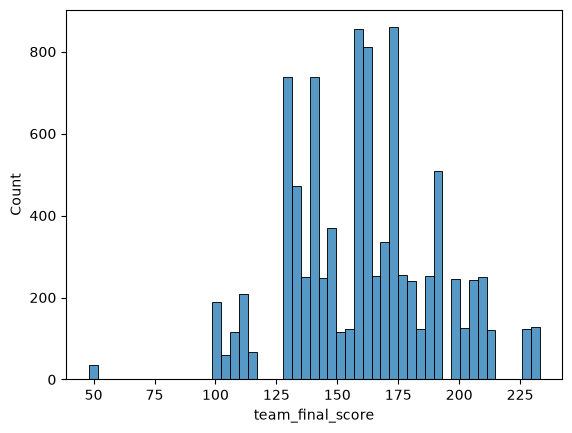

In [549]:
sns.histplot(df_copy[df_copy['stage']!='group_stage']['team_final_score'])
plt.show()

In [550]:
numeric_columns

Index(['match_id', 'innings', 'bat_pos', 'runs_batter', 'balls_faced',
       'valid_ball', 'runs_extras', 'runs_total', 'runs_bowler', 'year',
       'team_runs', 'team_balls', 'team_wicket', 'batter_runs',
       'batter_balls'],
      dtype='str')

In [551]:
df_copy.isnull().sum()

match_id                  0
innings                   0
batting_team              0
bowling_team              0
bat_pos                   0
runs_batter               0
balls_faced               0
bowler                    0
valid_ball                0
runs_extras               0
runs_total                0
runs_bowler               0
runs_not_boundary         0
wicket_kind          153045
player_out           153045
match_won_by           2735
win_outcome            2735
toss_decision             0
venue                     0
year                      0
stage                     0
team_runs                 0
team_balls                0
team_wicket               0
batter_runs               0
batter_balls              0
team_final_score          0
dtype: int64

In [552]:
df_copy['runs_total'].value_counts()

runs_total
1    67810
0    53317
4    19268
2    10326
6     9532
3      460
5      298
7       62
Name: count, dtype: int64

In [553]:
selected_features = [
    "innings",
    "batting_team",
    "bowling_team",
    "balls_faced",
    "bowler",
    "valid_ball",
    "runs_extras",
    "runs_total",
    "runs_bowler",
    "toss_decision",
    "venue",
    "year",
    "stage",
    "team_runs",
    "team_balls",
    "team_wicket",
    "batter_runs",
    "batter_balls",
    "team_final_score"
]

len(selected_features)

19

In [554]:
df_selected = df_copy[selected_features]
df_selected.head()

,innings,batting_team,bowling_team,balls_faced,bowler,valid_ball,runs_extras,runs_total,runs_bowler,toss_decision,venue,year,stage,team_runs,team_balls,team_wicket,batter_runs,batter_balls,team_final_score
122502,1,MI,RPS,1,RP Singh,1,0,1,1,1,Wankhede Stadium,2016,group_stage,1,1,0,1,1,121
122503,1,MI,RPS,1,RP Singh,1,0,0,0,1,Wankhede Stadium,2016,group_stage,1,2,0,0,1,121
122504,1,MI,RPS,1,RP Singh,1,0,2,2,1,Wankhede Stadium,2016,group_stage,3,3,0,2,2,121
122505,1,MI,RPS,1,RP Singh,1,0,4,4,1,Wankhede Stadium,2016,group_stage,7,4,0,6,3,121
122506,1,MI,RPS,1,RP Singh,1,0,1,1,1,Wankhede Stadium,2016,group_stage,8,5,0,7,4,121


In [555]:
df_selected.duplicated().sum()

np.int64(0)

In [556]:
df_selected = df_selected.drop_duplicates()
df_selected.duplicated().sum()

np.int64(0)

<Axes: >

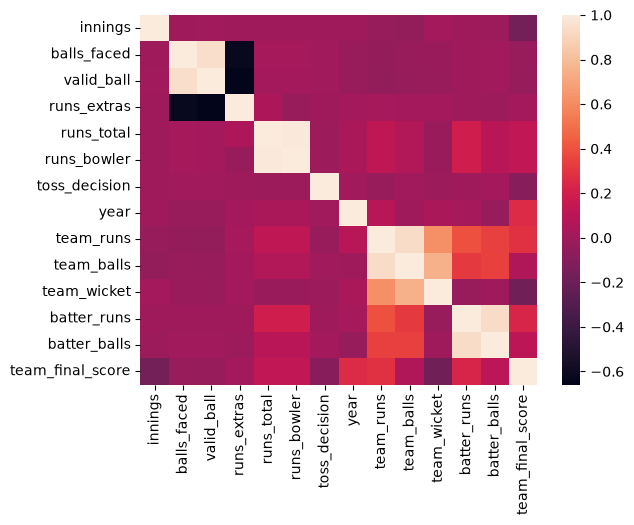

In [557]:
sns.heatmap(df_selected.corr(numeric_only=True))

In [558]:

for col in df_selected.select_dtypes(include="object").columns:
    df_selected[col] = le.fit_transform(df_selected[col])

df_selected.head()

,innings,batting_team,bowling_team,balls_faced,bowler,valid_ball,runs_extras,runs_total,runs_bowler,toss_decision,venue,year,stage,team_runs,team_balls,team_wicket,batter_runs,batter_balls,team_final_score
122502,1,6,9,1,269,1,0,1,1,1,37,2016,4,1,1,0,1,1,121
122503,1,6,9,1,269,1,0,0,0,1,37,2016,4,1,2,0,0,1,121
122504,1,6,9,1,269,1,0,2,2,1,37,2016,4,3,3,0,2,2,121
122505,1,6,9,1,269,1,0,4,4,1,37,2016,4,7,4,0,6,3,121
122506,1,6,9,1,269,1,0,1,1,1,37,2016,4,8,5,0,7,4,121


In [559]:
df_selected = df_selected.astype(int)
df_selected.dtypes

innings             int64
batting_team        int64
bowling_team        int64
balls_faced         int64
bowler              int64
valid_ball          int64
runs_extras         int64
runs_total          int64
runs_bowler         int64
toss_decision       int64
venue               int64
year                int64
stage               int64
team_runs           int64
team_balls          int64
team_wicket         int64
batter_runs         int64
batter_balls        int64
team_final_score    int64
dtype: object

In [ ]:
df_selected.to_csv("../ipl_data/ipl_last_10_years_cleaned.csv", index=False)